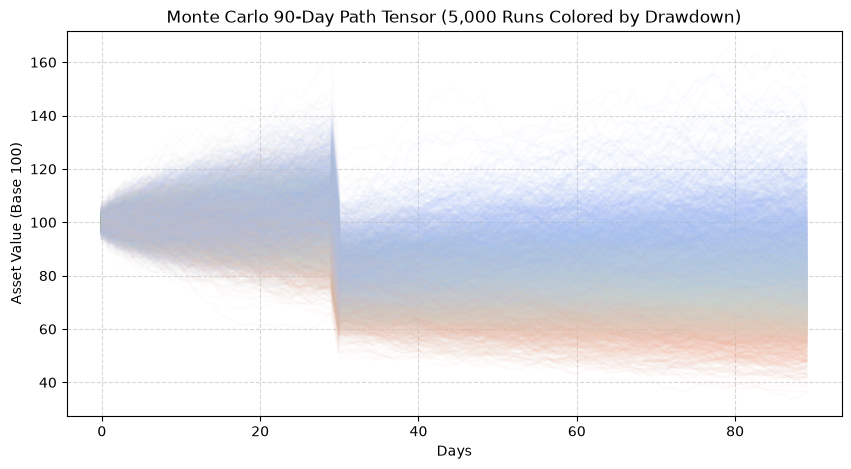

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 1. Resolve project root and load the master tensor from data/raw/
project_root = Path().resolve().parent
tensor_path = project_root / "data" / "raw" / "master_path_tensor.npy"
master_tensor = np.load(tensor_path)

# 2. Extract paths for Node 0 (Shape: 5000 runs x 90 days)
node_0_paths = master_tensor[0]

# 3. Calculate max drawdown per path to use as a color weight
running_max = np.maximum.accumulate(node_0_paths, axis=1)
drawdowns = (node_0_paths - running_max) / running_max
max_dds = np.min(drawdowns, axis=1)  # Shape: (5000,)

# 4. Plot the paths colored by drawdown severity
plt.figure(figsize=(10, 5))
for i in range(5000):
    plt.plot(
        node_0_paths[i], color=plt.cm.coolwarm(np.abs(max_dds[i]) / 0.8), alpha=0.03
    )

plt.title("Monte Carlo 90-Day Path Tensor (5,000 Runs Colored by Drawdown)")
plt.xlabel("Days")
plt.ylabel("Asset Value (Base 100)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()